# Introduction to Python Project : FoodHub Data Analysis

Mounted at /content/drive


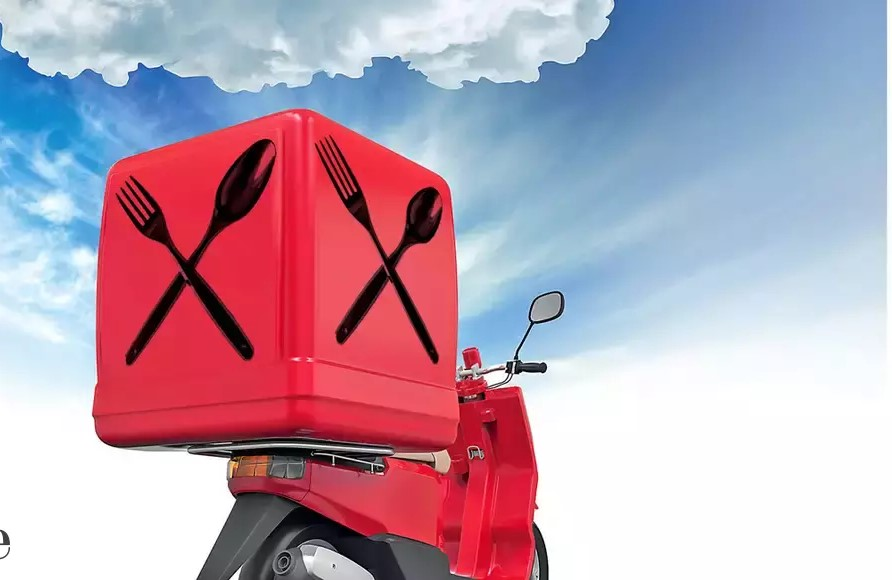

In [6]:
# mounting goodle drive , code to import the image
from google.colab import drive
drive.mount('/content/drive')
from IPython.display import Image
Image('/content/drive/My Drive/Colab Notebooks/FoodHub/Food.jpg')

### Problem Statement

Write the problem statement and objectives here


The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience.

### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [7]:
# Write your code here to import necessary libraries for the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Understanding the structure of the data

In [8]:
# Write your code here to read the data
df=pd.read_csv('/content/drive/My Drive/Colab Notebooks/FoodHub/foodhub_order.csv')

In [9]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [10]:
# Write your code here to view the last 5 rows
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [11]:
# Write your code here to understand the shape of the data
df.shape

(1898, 9)

#### Observations:


There are 1898 number of rows and 9 number of columns present in the data

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [12]:
# Write your code here for infomation on the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


The data types of different colummns in the data set are integers, strings, objects and float.
float: 1 column
integers: 4 columns
objects: 4, which are possibly of string data types.

The rating column should be on type integer whereas it is of type string object, this needs to be analysed further.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [13]:
#check for null values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [14]:

# check for duicate values
df[df['order_id'].duplicated() == True]

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time


#### Observations:


There are no missing values in the data set. Total number of columns in the data set is 9 and there all no null values present across each column.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [15]:
# Write your code here
# describe the date set with all columns
df.describe(include="all")


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898,1898,1898.000000,1898,1898,1898.000000,1898.000000
unique,NaN,NaN,178,14,NaN,2,4,NaN,NaN
top,NaN,NaN,Shake Shack,American,NaN,Weekend,Not given,NaN,NaN
freq,NaN,NaN,219,584,NaN,1351,736,NaN,NaN
mean,1.477496e+06,171168.478398,NaN,NaN,16.498851,NaN,NaN,27.371970,24.161749
std,5.480497e+02,113698.139743,NaN,NaN,7.483812,NaN,NaN,4.632481,4.972637
min,1.476547e+06,1311.000000,NaN,NaN,4.470000,NaN,NaN,20.000000,15.000000
25%,1.477021e+06,77787.750000,NaN,NaN,12.080000,NaN,NaN,23.000000,20.000000
50%,1.477496e+06,128600.000000,NaN,NaN,14.140000,NaN,NaN,27.000000,25.000000
75%,1.477970e+06,270525.000000,NaN,NaN,22.297500,NaN,NaN,31.000000,28.000000


Food Preparation Minimum Time is : 20 minutes
Average Time is : 27 minutes and  Maximum Time is : 35 minutes

In [16]:
# describe the date set with all columns and transposed view for readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [20]:
# print the dateset's statisicial insights
print('Cost Or Order  Mean:',df['cost_of_the_order'].mean())
print('Cost Or Order  Standard deviation:',df['cost_of_the_order'].std())
print('Cost Or Order  Median:',df['cost_of_the_order'].median())
print('Food Preparation Time  Mean:',df['food_preparation_time'].mean())
print('Food Preparation Time  Standard deviation:',df['food_preparation_time'].std())
print('Food Preparation Time Median:',df['food_preparation_time'].median())
print('Deivery Time  Mean:',df['delivery_time'].mean())
print('Deivery Time  Standard deviation:',df['delivery_time'].std())
print('Deivery Time Median:',df['delivery_time'].median())

Cost Or Order  Mean: 16.498851422550054
Cost Or Order  Standard deviation: 7.48381211004957
Cost Or Order  Median: 14.14
Food Preparation Time  Mean: 27.371970495258168
Food Preparation Time  Standard deviation: 4.6324807759288555
Food Preparation Time Median: 27.0
Deivery Time  Mean: 24.161749209694417
Deivery Time  Standard deviation: 4.972636933991106
Deivery Time Median: 25.0


#### Observations:
Food Preparation Minimum Time is : 20 minutes Average Time is : 27 minutes and Maximum Time is : 35 minutes

In [21]:
# Drop order_id & customer_id column since these are identifier column
dfSub=df.drop(['order_id','customer_id'],axis=1)
dfSub.describe().T

,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.0,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
food_preparation_time,1898.0,27.371970,4.632481,20.00,23.00,27.00,31.0000,35.00
delivery_time,1898.0,24.161749,4.972637,15.00,20.00,25.00,28.0000,33.00




*   The minimun time for food preparation is nealy 20 minutes and the maximum time for the same is 35 minutes.
*   The average time for food preparation  is nearly 27 minutes and 40 seconds.
*   The differerne between mean and median values of food preparation time is minimal
*   The cost of order has a wide range minimum being 4.47 units and maximum being 35.41 units
*   Delivery time ranges between 15 minutes to 33 minutes with an average of 24 minutes
*   We need to do more analysis ahead to understand the skewness of the dataset

*   The top restaurant in demand is Shake Shack
*   The American cuisine is demanded modt frequently
*   Weekends are when most of the demands are placed by customers.



















### **Question 5:** How many orders are not rated? [1 mark]

In [24]:
# Write the code here
#Get the unique values fr rating column
ratingGiven=df['rating'].unique()
ratingGiven

array(['Not given', '5', '3', '4'], dtype=object)

In [25]:
#print length of the dateset where rating column is Not given
print( len(df[df['rating'] == 'Not given']))

736


In [26]:
#Another way to analyze the length of the dateset where rating column is Not given
print(df[df.rating=='Not given'].value_counts)

<bound method DataFrame.value_counts of       order_id  customer_id             restaurant_name cuisine_type  \
0      1477147       337525                     Hangawi       Korean   
1      1477685       358141   Blue Ribbon Sushi Izakaya     Japanese   
6      1477894       157711           The Meatball Shop      Italian   
10     1477895       143926  Big Wong Restaurant _¤¾Ñ¼      Chinese   
14     1478198        62667      Lucky's Famous Burgers     American   
...        ...          ...                         ...          ...   
1887   1476873       237616                 Shake Shack     American   
1891   1476981       138586                 Shake Shack     American   
1892   1477473        97838                 Han Dynasty      Chinese   
1895   1477819        35309           Blue Ribbon Sushi     Japanese   
1897   1478056       120353           Blue Ribbon Sushi     Japanese   

      cost_of_the_order day_of_the_week     rating  food_preparation_time  \
0                 

In [27]:
# Calculate the percentatge of orders which do not have the rating.
736/1898*100

38.77766069546891

#### Observations:


There are 736 number of orders that are not rated.
About 38.78 percent rating data is not availabile for the analysis.
Rating is traditionaly a numerical variable whereas with 38.78% data with 'Not given' the rating column data is not useful at this stage.
Further analysis needs to be done ahead for an approach how to treat the rating column data and if there is a possible way to treat the 'Not given' values with any suitable replacement value.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [30]:
# Write the code here
# describing again to avoid scolling up again
dfSub.describe()

,cost_of_the_order,food_preparation_time,delivery_time
count,1898.000000,1898.000000,1898.000000
mean,16.498851,27.371970,24.161749
std,7.483812,4.632481,4.972637
min,4.470000,20.000000,15.000000
25%,12.080000,23.000000,20.000000
50%,14.140000,27.000000,25.000000
75%,22.297500,31.000000,28.000000
max,35.410000,35.000000,33.000000


In [31]:
df.describe(include='all')

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898,1898,1898.000000,1898,1898,1898.000000,1898.000000
unique,NaN,NaN,178,14,NaN,2,4,NaN,NaN
top,NaN,NaN,Shake Shack,American,NaN,Weekend,Not given,NaN,NaN
freq,NaN,NaN,219,584,NaN,1351,736,NaN,NaN
mean,1.477496e+06,171168.478398,NaN,NaN,16.498851,NaN,NaN,27.371970,24.161749
std,5.480497e+02,113698.139743,NaN,NaN,7.483812,NaN,NaN,4.632481,4.972637
min,1.476547e+06,1311.000000,NaN,NaN,4.470000,NaN,NaN,20.000000,15.000000
25%,1.477021e+06,77787.750000,NaN,NaN,12.080000,NaN,NaN,23.000000,20.000000
50%,1.477496e+06,128600.000000,NaN,NaN,14.140000,NaN,NaN,27.000000,25.000000
75%,1.477970e+06,270525.000000,NaN,NaN,22.297500,NaN,NaN,31.000000,28.000000


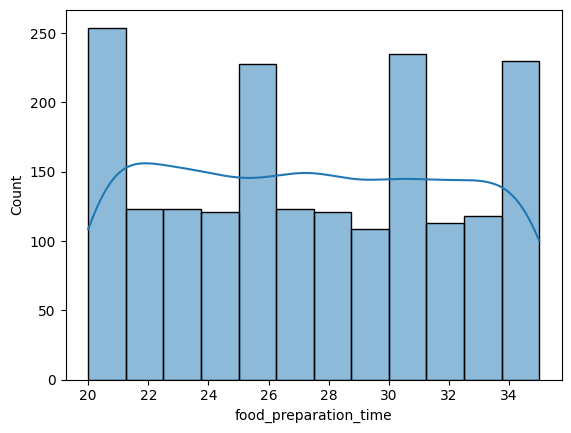

In [32]:
sns.histplot(data=df,x='food_preparation_time',kde=True);

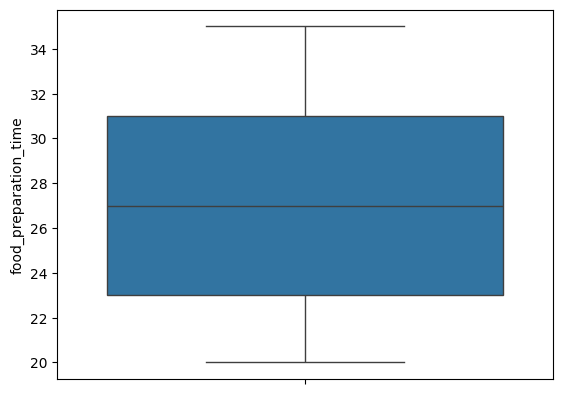

In [33]:
sns.boxplot(data=df,y='food_preparation_time');

Food preparation time varies from 20 minutes to 35 minutes; There are no outliers which suggests that there are no orders which have taken too much time for prepation.
25% of food prepation time is near about 22 minutes and 75% of food prepation time is 31 minutes.
Average time of food prepartion time is about 27 minutes

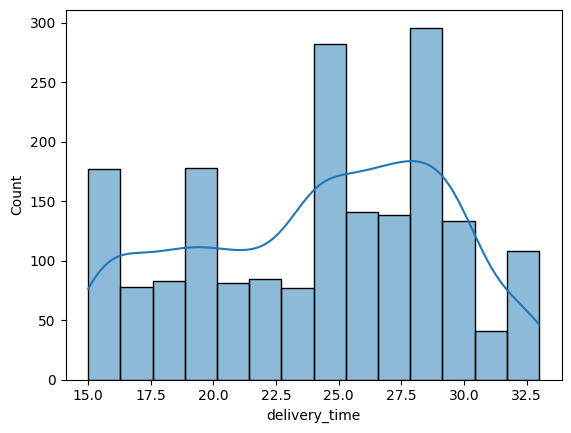

In [ ]:
sns.histplot(data=df,x='delivery_time',kde=True);

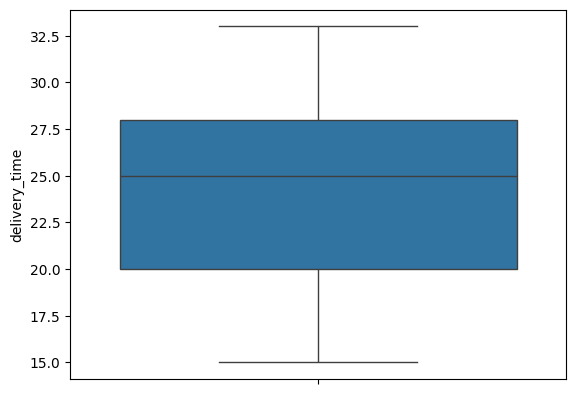

In [ ]:
sns.boxplot(data=df,y='delivery_time');

The delivery time varies from 15 minutes to 33 minutes; There are no outliers which suggests that there are no orders which have taken too much time for delivery.

25% of delivery  time is near about 20 minutes and 75% of delivery time is 27 and half a minutes.
Avetage time of delivery time is about 24 minutes

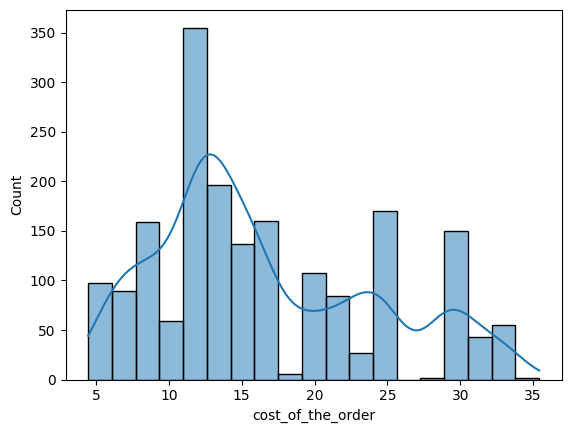

In [ ]:
sns.histplot(data=df,x='cost_of_the_order',kde=True);

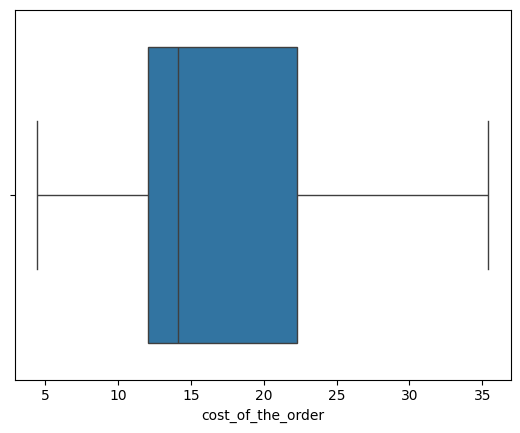

In [ ]:
sns.boxplot(data=df,x='cost_of_the_order');

The cost of the order varies from 5 unit of price to to 35 dollars; There are no outliers which suggests that there are no orders which were exceptionally higt cost. Cot varies from 5 minutes to 35 Units; The 25% of costs are near about 11 dollars and 75% of cost is 23 dollars. Average cost of order is about 14 dollars.

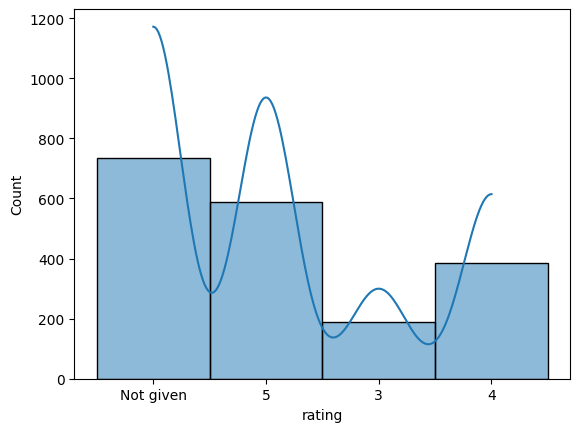

In [ ]:
sns.histplot(data=df,x='rating',kde=True);

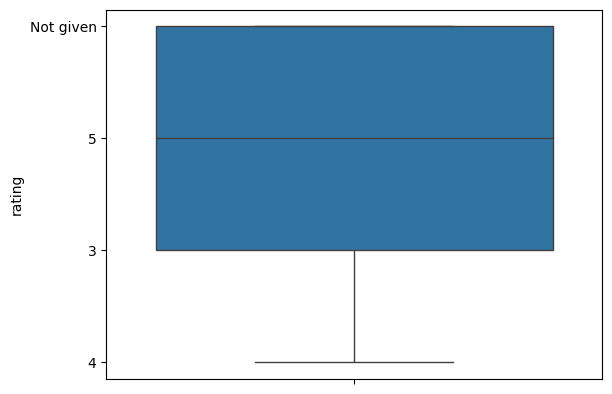

In [ ]:
sns.boxplot(data=df,y='rating');

The rating data is not available for a large number of orders.

In [36]:
# Analysing all the unique cuisine types in the dataset
df['cuisine_type'].unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

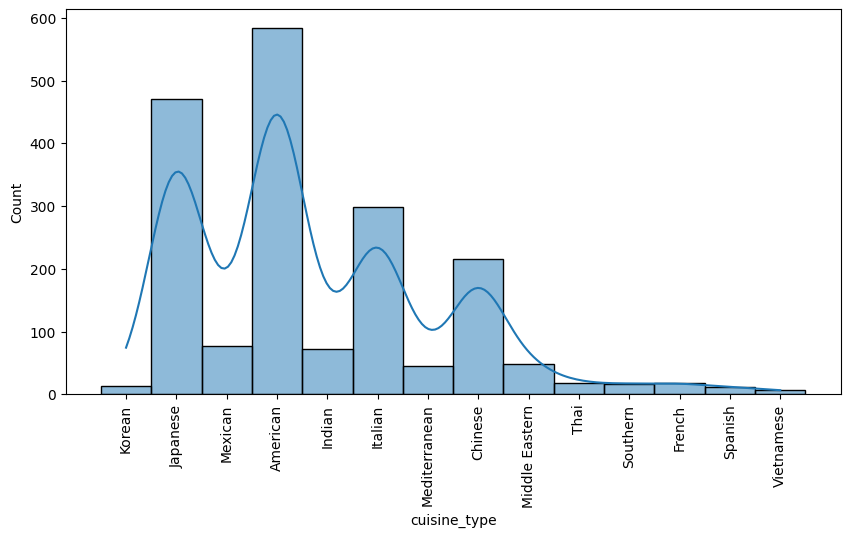

In [37]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='cuisine_type',kde=True);
plt.xticks(rotation=90)
plt.show()


There are multiple modes in the cuisine_type in the present dataset.

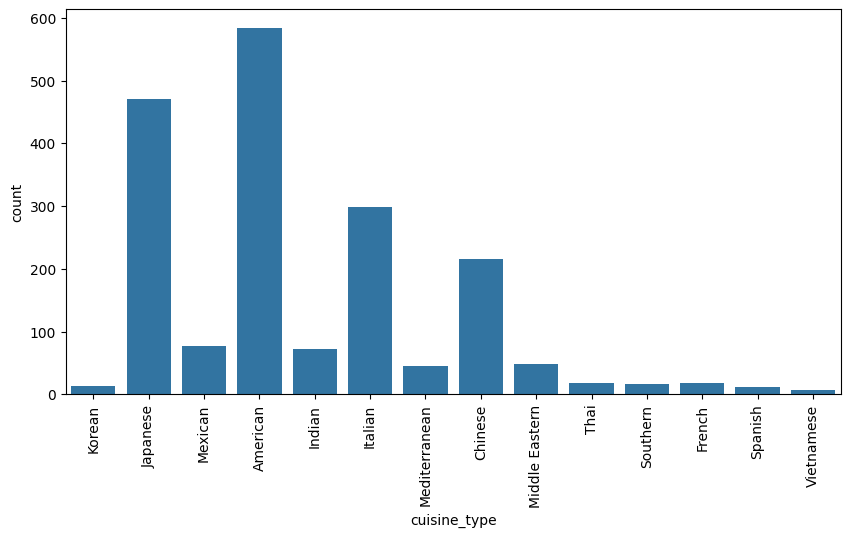

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='cuisine_type');
plt.xticks(rotation=90)
plt.show()

In [39]:
#find unique restaurants in the dataset
restaurant=df['restaurant_name'].unique()
len(restaurant)

178

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


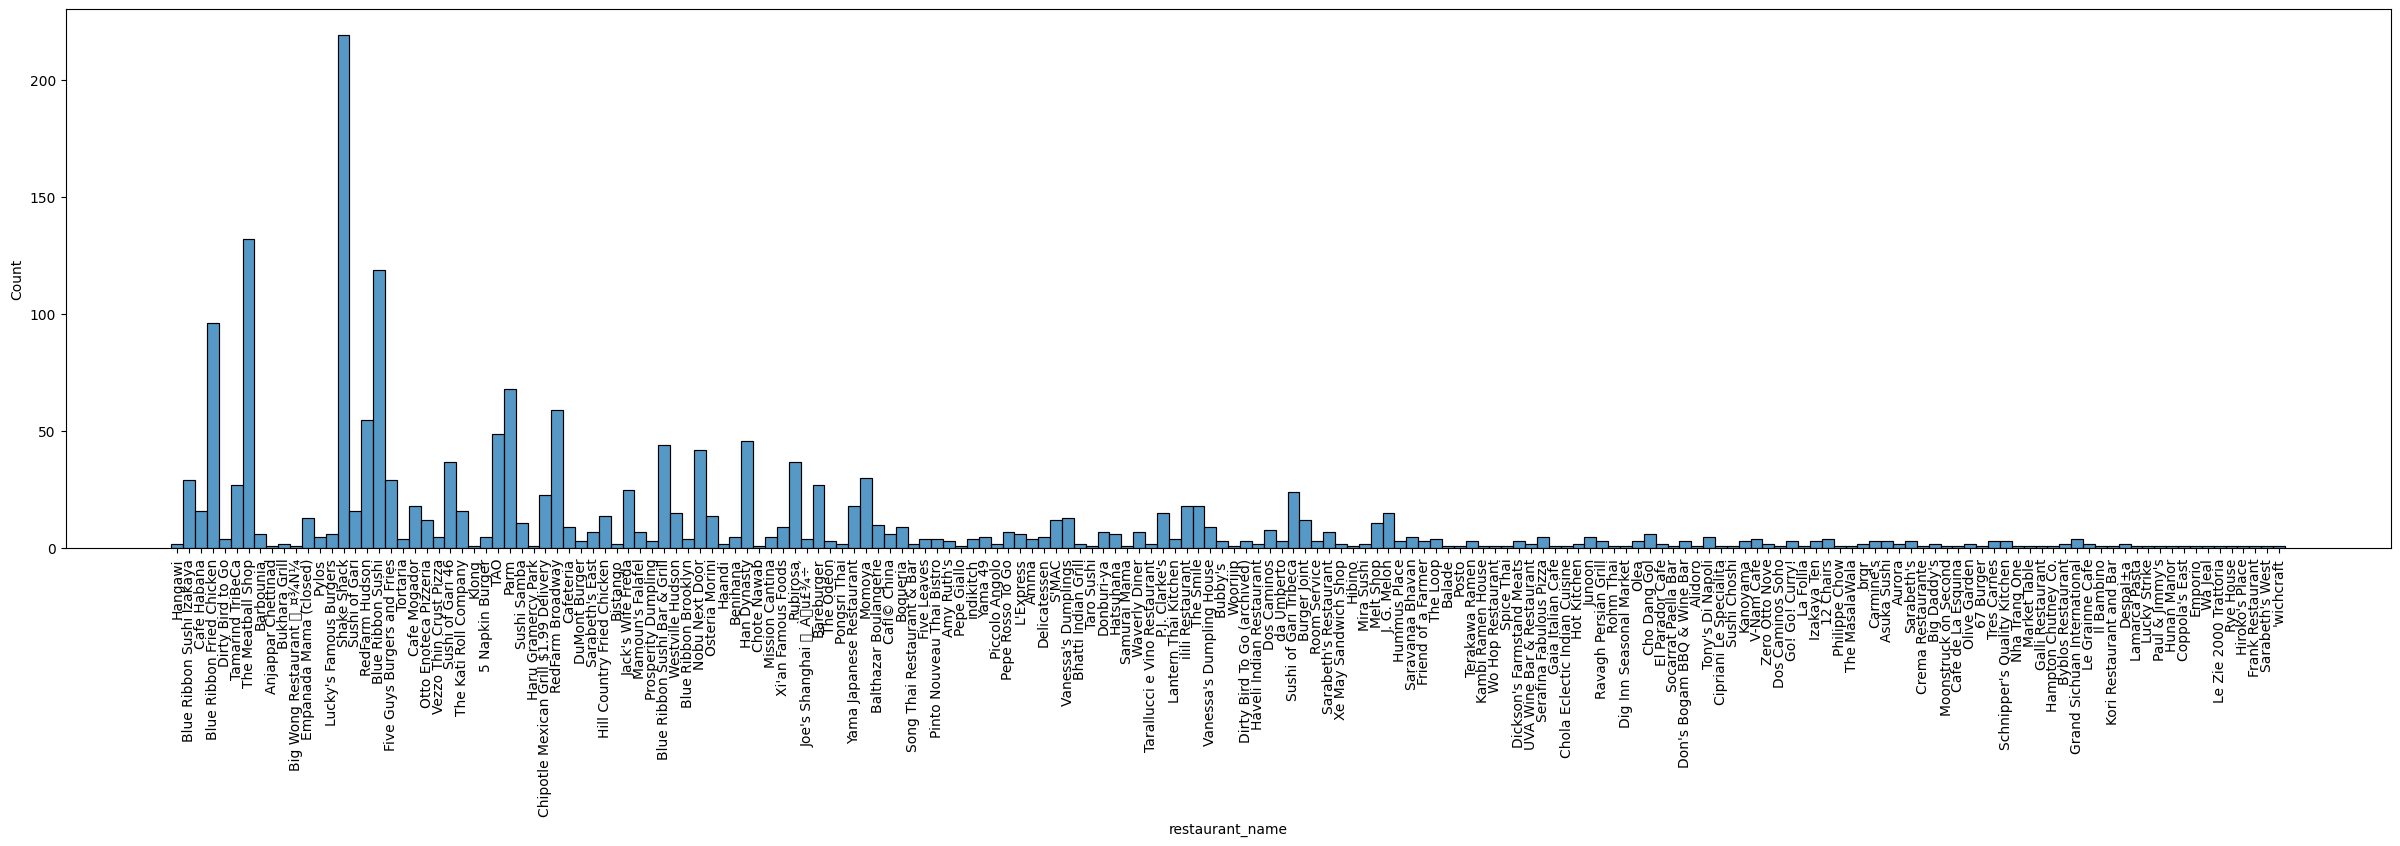

In [40]:
plt.figure(figsize=(30,7))
sns.histplot(data=df,x='restaurant_name');
plt.xticks(rotation=90)
plt.show()

There are total 178 numbers of restaurants from which the food aggregator serves order from.
There are several restaurants from which small counts of orders are placed by customers.

In [41]:
#Count Orders for each restaurants
grouped = df.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False)
grouped

,order_id
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Klong,1
Kambi Ramen House,1
Il Bambino,1


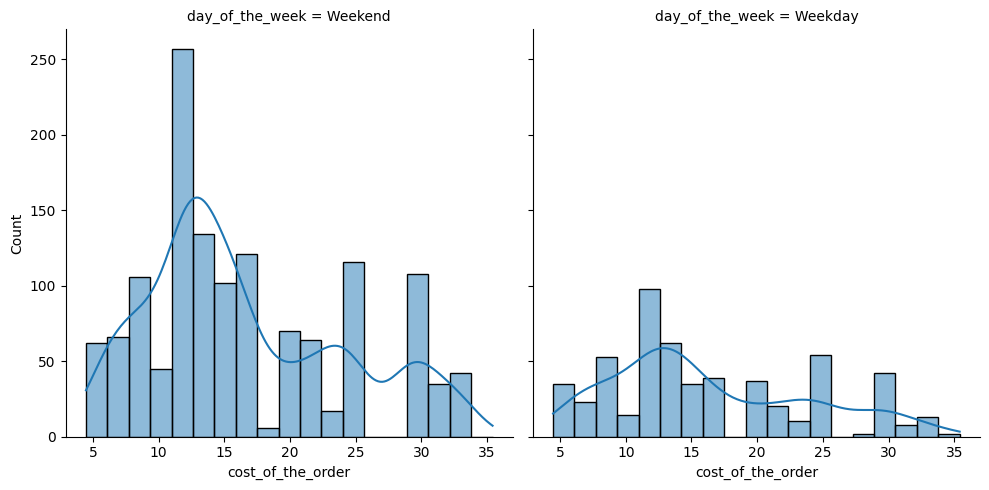

In [42]:
sns.displot(data=df, x="cost_of_the_order", col="day_of_the_week", kde=True);

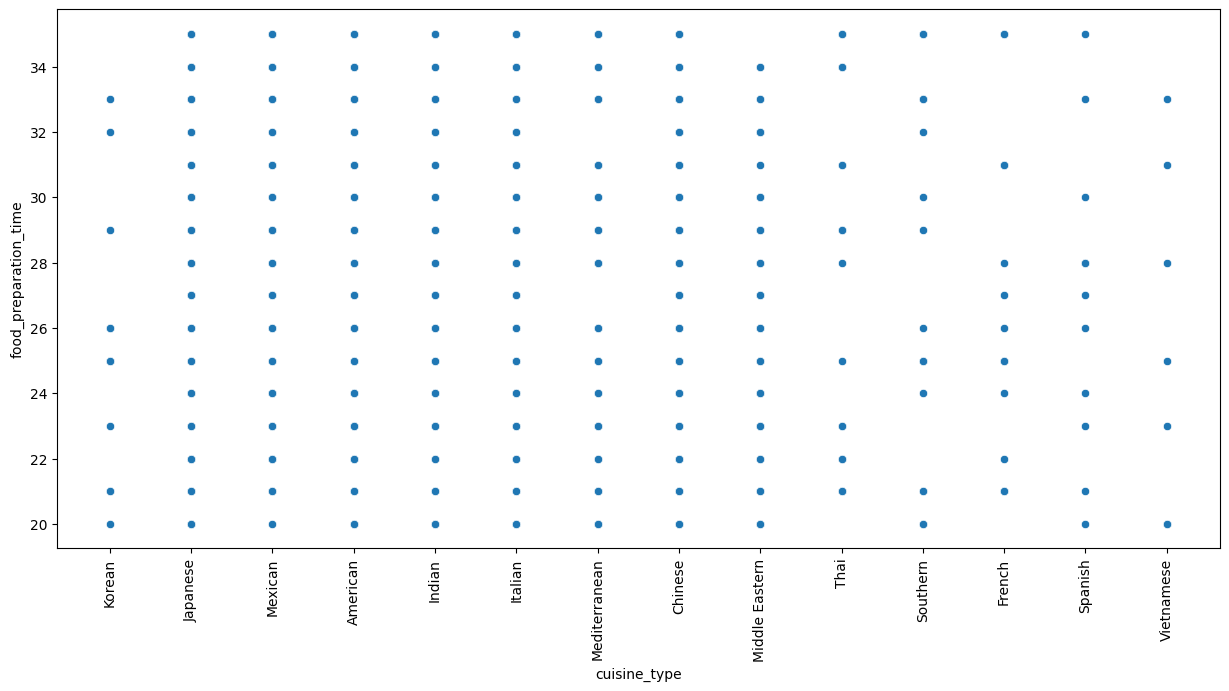

In [43]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='cuisine_type',y='food_preparation_time');
plt.xticks(rotation=90)
plt.show()

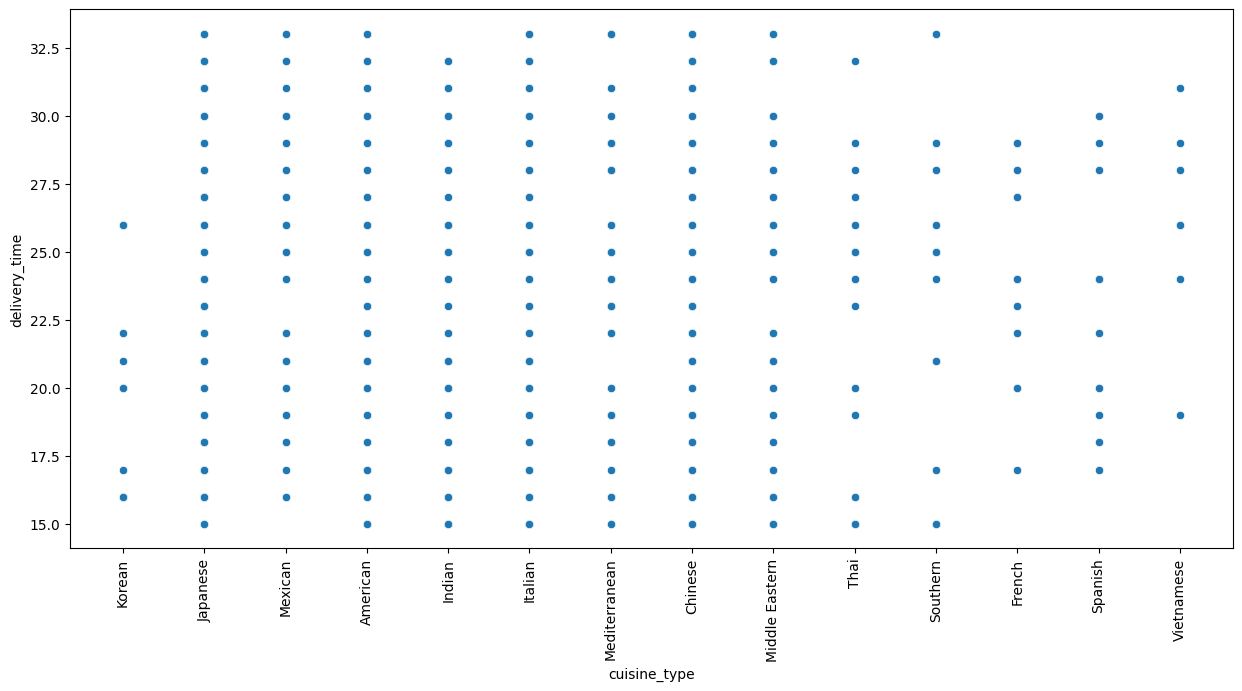

In [44]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df,x='cuisine_type',y='delivery_time');
plt.xticks(rotation=90)
plt.show()

Food Preparation Time and Delivery time are consistent across cuisine type.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


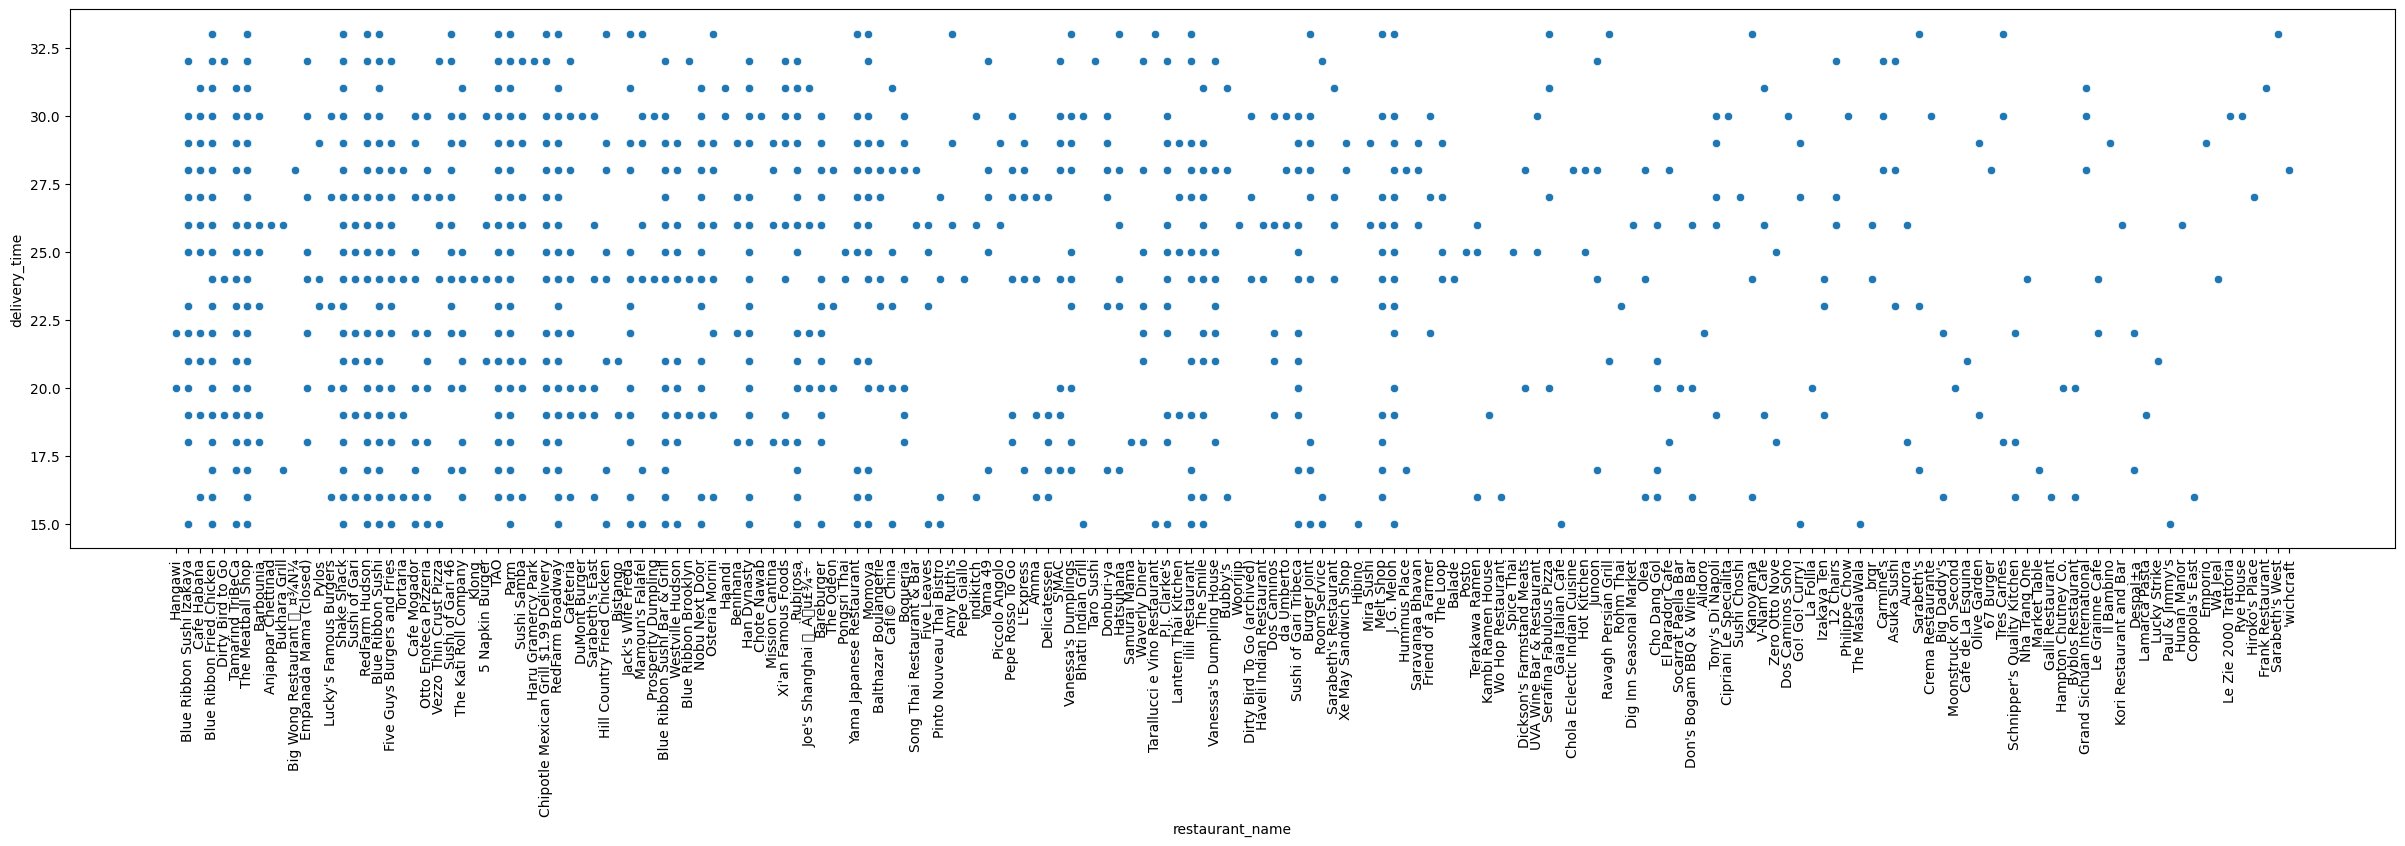

In [45]:
plt.figure(figsize=(30,7))
sns.scatterplot(data=df,x='restaurant_name',y='delivery_time');
plt.xticks(rotation=90)
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


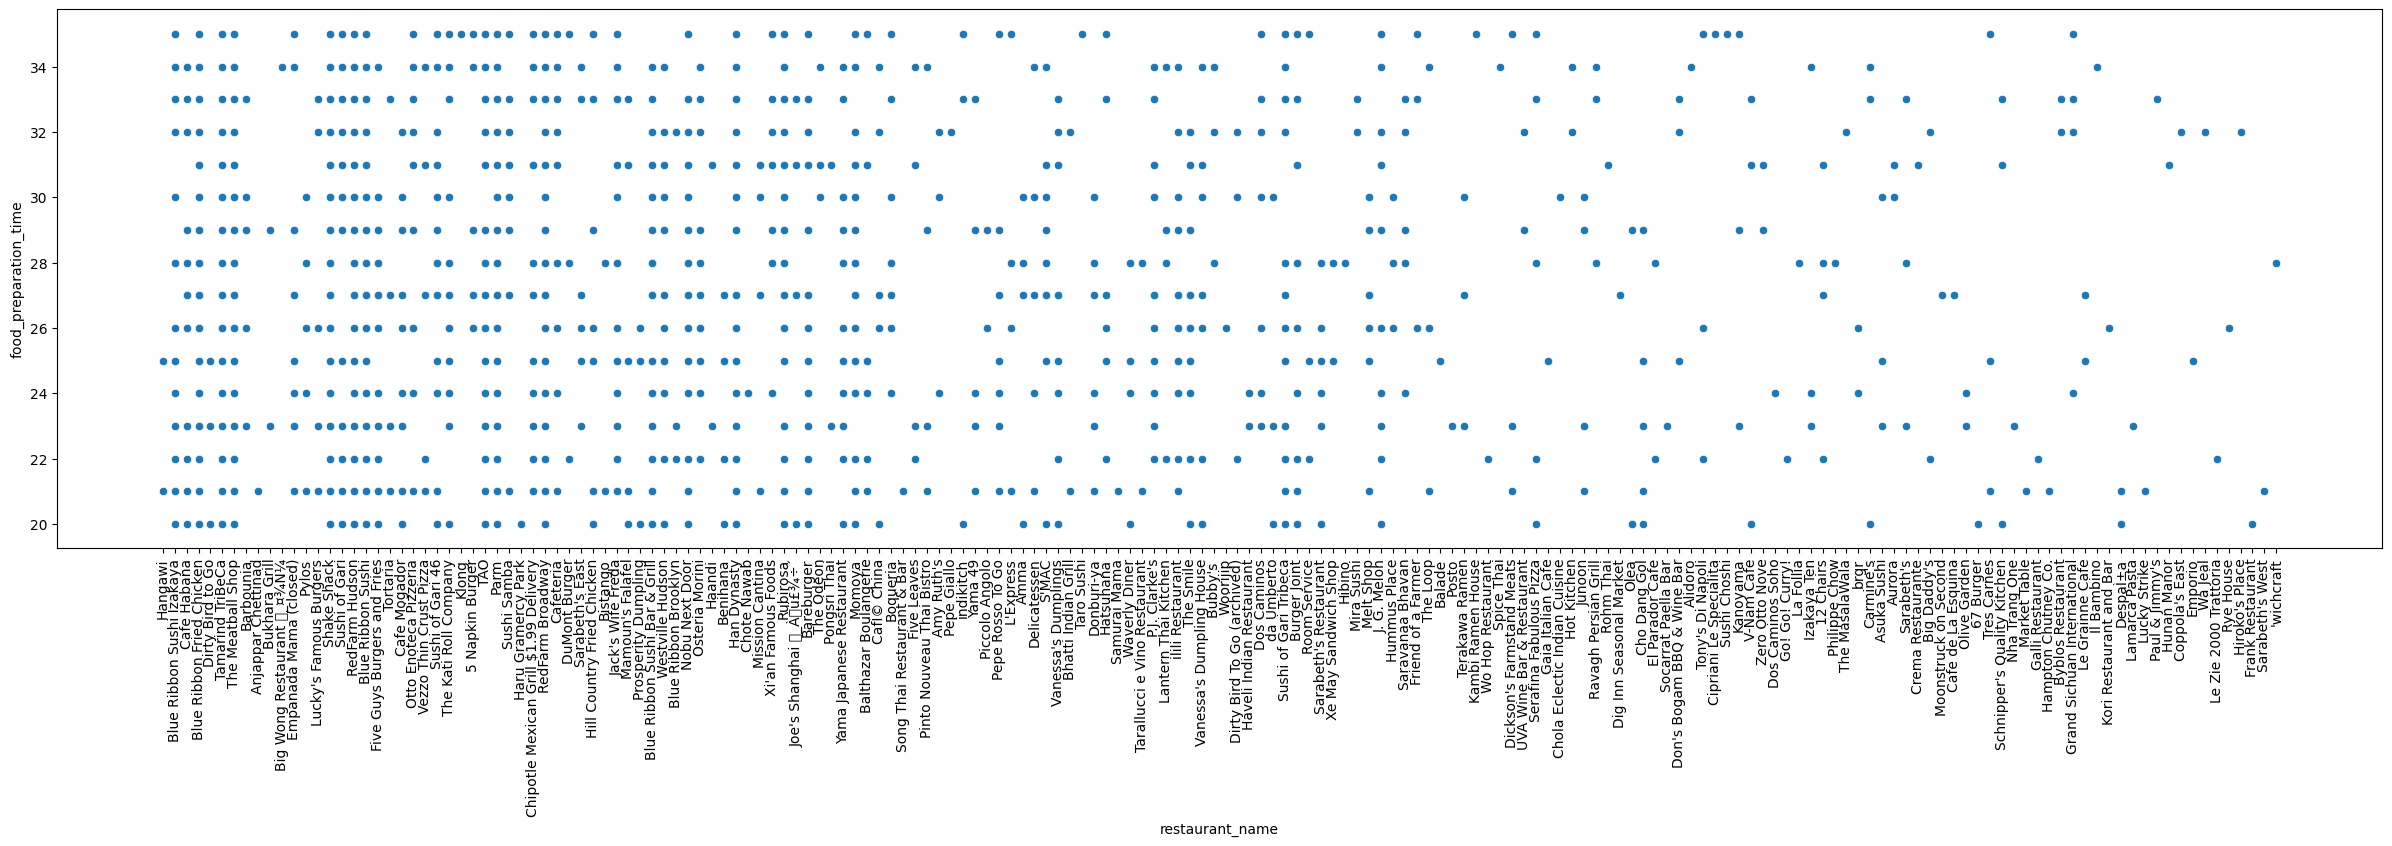

In [46]:
plt.figure(figsize=(30,7))
sns.scatterplot(data=df,x='restaurant_name',y='food_preparation_time');
plt.xticks(rotation=90)
plt.show()

Food preparationtime and delivery time variance is consistent across restaurants.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [48]:
# Write the code here
# With option context in pandas , printing all rows for analysis
grouped = df.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False)
grouped
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
  print(grouped)

restaurant_name
Shake Shack                              219
The Meatball Shop                        132
Blue Ribbon Sushi                        119
Blue Ribbon Fried Chicken                 96
Parm                                      68
RedFarm Broadway                          59
RedFarm Hudson                            55
TAO                                       49
Han Dynasty                               46
Blue Ribbon Sushi Bar & Grill             44
Nobu Next Door                            42
Rubirosa                                  37
Sushi of Gari 46                          37
Momoya                                    30
Blue Ribbon Sushi Izakaya                 29
Five Guys Burgers and Fries               29
Bareburger                                27
Tamarind TriBeCa                          27
Jack's Wife Freda                         25
Sushi of Gari Tribeca                     24
Chipotle Mexican Grill $1.99 Delivery     23
Cafe Mogador                           

#### Observations:
The top 5 restaurants in terms of number of orders received are


  Shake Shack,
  The Meatball shop,
  Blue Ribbon Sushi,
  Blue Ribbon Fried Chicken and
  Parm

There are several restaurants from where customers have ordered only 1 order.
There are several restaurants from where customers have ordered less than 6 orders.



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

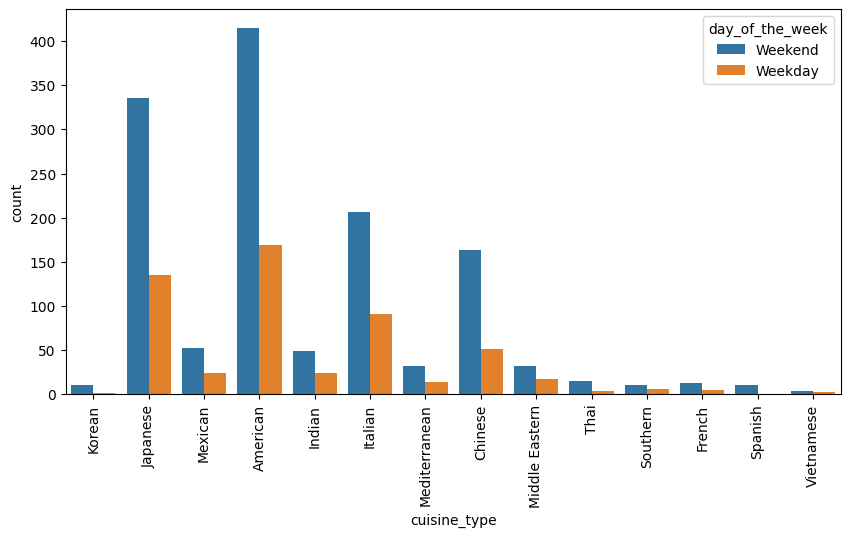

In [49]:
# Write the code here
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

#### Observations:
American cuisine is the most popular on weekends.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [50]:
# Write the code here
dfCost=df[['order_id','cost_of_the_order']]
count20=dfCost.loc[dfCost['cost_of_the_order']>20]
print(count20)
print(count20.count()/dfCost.count()*100) # One method of calaculation
print(555/1898) # Cross verifying the calculation with 2nd method


      order_id  cost_of_the_order
0      1477147              30.75
3      1477334              29.20
5      1477224              25.22
12     1476966              24.30
17     1477373              33.03
...        ...                ...
1884   1477437              31.43
1885   1477550              29.05
1892   1477473              29.15
1893   1476701              22.31
1895   1477819              25.22

[555 rows x 2 columns]
order_id             29.241307
cost_of_the_order    29.241307
dtype: float64
0.2924130663856691


In [51]:
#Calculating revenue generated though the total number of order placed for each restaurant
restCost=df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
  print(restCost)

restaurant_name
Shake Shack                              3579.53
The Meatball Shop                        2145.21
Blue Ribbon Sushi                        1903.95
Blue Ribbon Fried Chicken                1662.29
Parm                                     1112.76
RedFarm Broadway                          965.13
RedFarm Hudson                            921.21
TAO                                       834.50
Han Dynasty                               755.29
Blue Ribbon Sushi Bar & Grill             666.62
Rubirosa                                  660.45
Sushi of Gari 46                          640.87
Nobu Next Door                            623.67
Five Guys Burgers and Fries               506.47
Momoya                                    492.13
Chipotle Mexican Grill $1.99 Delivery     491.69
Blue Ribbon Sushi Izakaya                 485.09
Tamarind TriBeCa                          426.71
Jack's Wife Freda                         416.75
Bareburger                                399.74
Sush

#### Observations:
29.24 Percentage of the orders cost more that 20 Dollars
The restaurnats such as Kambi Rames house, Empario, Bhatti Indian Grill, Harus Gramerrcy park and Luchy Strike where the average cost per order is high.



### **Question 10**: What is the mean order delivery time? [1 mark]

In [53]:
# Write the code here
# Calculating the mean and converting the mean value to string to print
print("The mean order delivery time is :"+str(df['delivery_time'].mean())+" minutes")

The mean order delivery time is :24.161749209694417 minutes


#### Observations:


The mean order delivery time is 24 minutes approximately.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [54]:
# Write the code here
# Using groupby customer_id in the dataframe for orders
df.groupby(['customer_id'])['order_id'].count().sort_values(ascending=False)

,order_id
customer_id,
52832,13
47440,10
83287,9
250494,8
65009,7
...,...
105903,1
105992,1
106006,1


#### Observations:
Customer with customer_id 52832 placed 13 orders,

Customer with customer_id 47440 placed 10 orders and



Customer with customer_id 83287 placed 9 orders.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


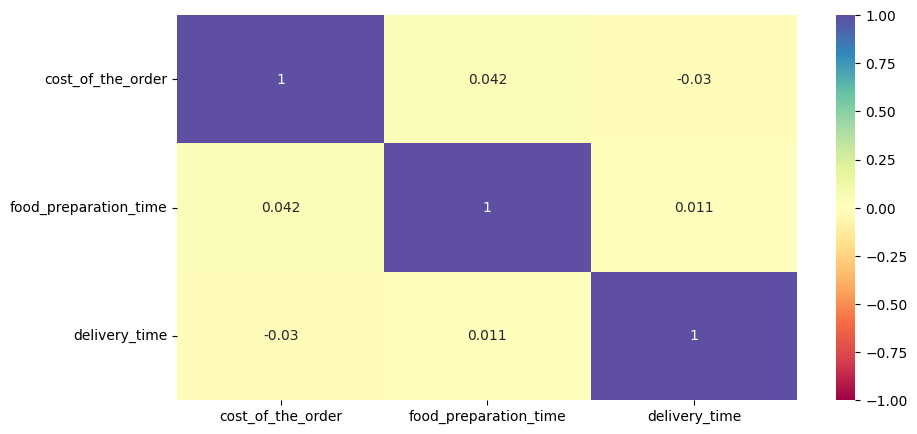

In [56]:
# Write the code here
# numeric columns in the data frame and heatmap
df_numeric = df._get_numeric_data()
df_numeric.drop(['order_id', 'customer_id'], axis=1, inplace=True)
df_numeric.reset_index(drop=True, inplace=True)
plt.figure(figsize=(10,5))
sns.heatmap(df_numeric.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

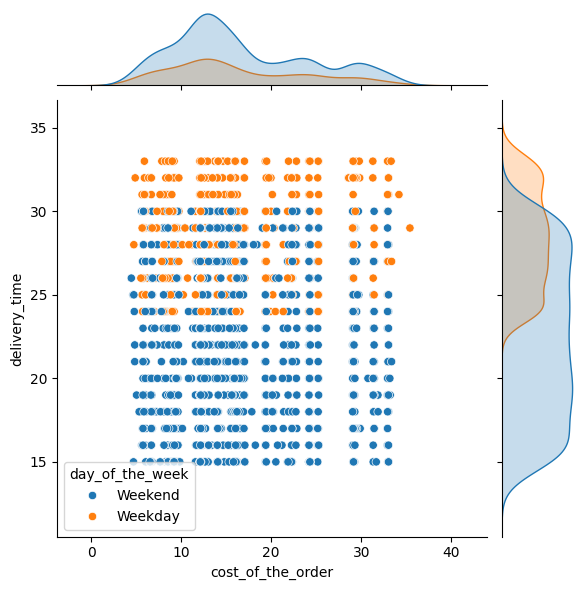

In [57]:
sns.jointplot(data=df,x='cost_of_the_order',y='delivery_time',hue='day_of_the_week');

During Weekdays the delivery time is longer than that of weekends.

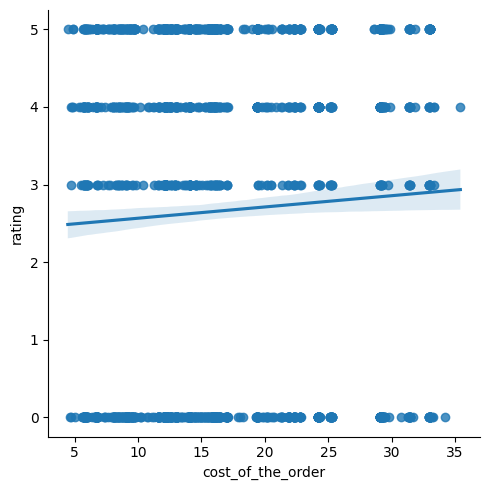

In [58]:
#replacing rating not given value with 0, and converting the rating colun to a numeric type
dfRating=df
dfRating
dfRating['rating'] = dfRating['rating'].replace(['Not given'], '0')
dfRating['rating'] = dfRating['rating'].astype(int)
sns.lmplot(data=dfRating,x='cost_of_the_order',y='rating');

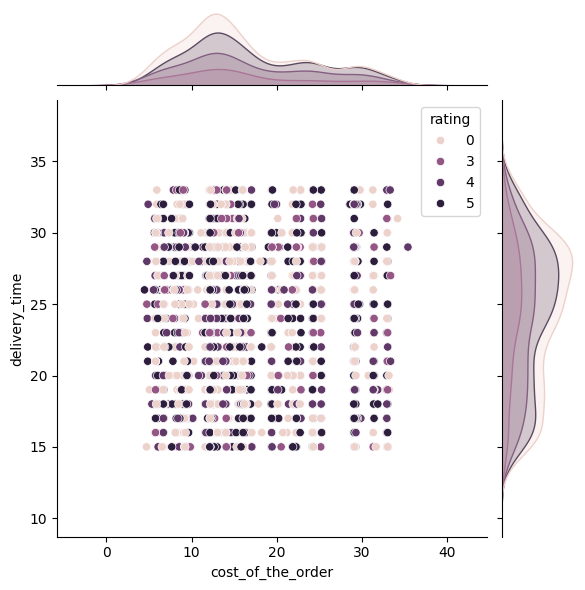

In [59]:
sns.jointplot(data=df,x='cost_of_the_order',y='delivery_time',hue='rating');

As per the heat map dlivery_time has a slight negative correlation with cost of the order. If the delivery time is more, customers are charged less for the order.

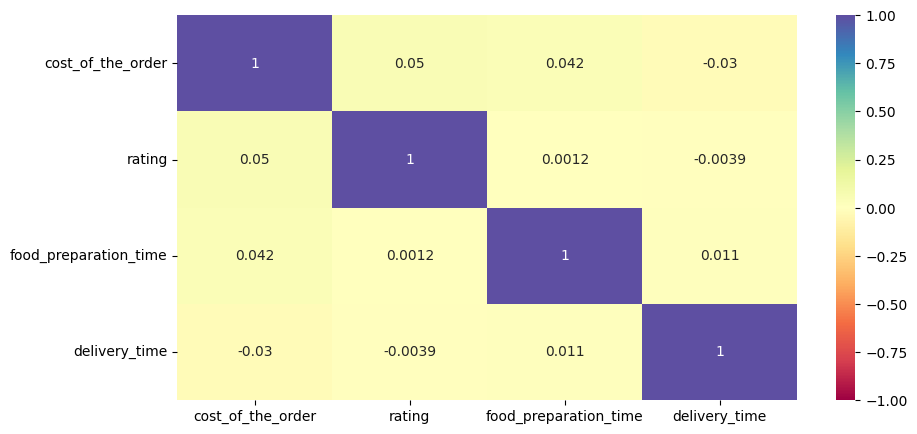

In [62]:
# Heatmap with rating column included as numeric column in the dataframe and finding correlation
df_numeric = dfRating._get_numeric_data()
df_numeric.drop(['order_id', 'customer_id'], axis=1, inplace=True)
df_numeric.reset_index(drop=True, inplace=True)
plt.figure(figsize=(10,5))
sns.heatmap(df_numeric.corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [63]:
# Write the code here
#print(dfRating.groupby(['restaurant_name'])['rating'].count().sort_values(ascending=False))
#print(dfRating.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending=False))
resultDf = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])
resultDf
print(resultDf.loc[(resultDf['count'] > 50) ])
print(resultDf.loc[(resultDf['mean'] > 4) ])


                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     96  2.885417
Blue Ribbon Sushi            119  2.588235
Parm                          68  2.367647
RedFarm Broadway              59  2.949153
RedFarm Hudson                55  2.581818
Shake Shack                  219  2.598174
The Meatball Shop            132  2.871212
                               count      mean
restaurant_name                               
'wichcraft                         1  5.000000
67 Burger                          1  5.000000
Anjappar Chettinad                 1  5.000000
Balade                             1  5.000000
Big Daddy's                        2  5.000000
Bukhara Grill                      2  5.000000
Cafe de La Esquina                 1  5.000000
Chola Eclectic Indian Cuisine      1  5.000000
Chote Nawab                        1  5.000000
Cipriani Le Specialita             1  5.000000
Dickson's Farmstand Meats          3  4.666667
Di

#### Observations:
There are no restaurants in the data set meeting the criteria for promotional offer.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [65]:
# Write the code here-of
#Finding orders which are greater than 20 dollars & 5 dollars, calculating revenue
dfCost20=df.loc[df['cost_of_the_order']>20]
dfCost5=df.loc[df['cost_of_the_order']>5]
print(dfCost20['cost_of_the_order'].sum()*0.25+dfCost5['cost_of_the_order'].sum()*0.15)

8379.539499999999


#### Observations:
The net revenue generated by the company across all order is 8370.53 Unit Of measure of the currency

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [67]:
# Write the code here
# Adding new column as total_time to the dataframe by adding food preparation time and delivery time
df['total_time']=df['food_preparation_time']+df['delivery_time']
print(df.shape)
dfCount60=df.loc[df['total_time']>60]
print(dfCount60.shape)
(200/1898)*100


(1898, 10)
(200, 10)


10.537407797681771

#### Observations:
Approximately 10.53 Percentage of orders take more than 60 minitues to get delivered from the time of the order is placed

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

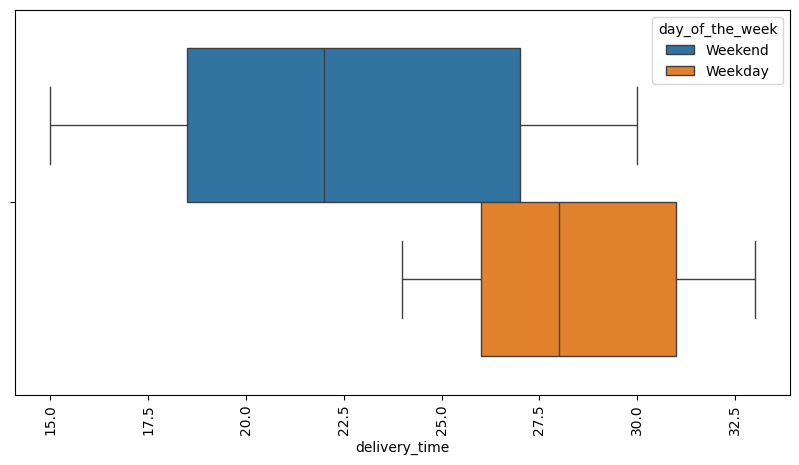

In [69]:
# Write the code here
# Box plot for mean identification
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='delivery_time',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

#### Observations:
The mean delivery time during weekdays is greater than the mean delivery time during weekends.
Mean delivery time during weekdays is near 28 minutes
Mean delivery time during weekends is near 21 and half minutes

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  The food aggregator delivery business caters several types of cuisines across many number restaurants to its customers.

*   The business is performing better over weekends due to large orders being placed by customers and delivery time being lesser
*   Some of the cases even-if the cost of the order is high, cusotmers ratings are higher, this insight can be used to generate more revenue.


*   Delivery time and food preparation time is consitent across the orders
*   A larger number of restaurants have received only a small number of orders from the customers.


*   For the most popular resturants which have served large number of orders, the ratings are not availale







### Recommendations:

*  The food aggregator should incentivise the customers who rate the order though promotional offers, so that ratings are given for each order. This rating data can help in operational excellence.


*   The food aggregator can promote the cuisine types which have high cost and rated higher to increase the number of orders, this will yield in more revenue
*   Improve the delivery time over the weekdays for the popular cuisines and retaurants fo that there are more orders get placed during weekdays also.



In [70]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")


IndexError: list index out of range